<a href="https://colab.research.google.com/github/majumdarmanjari14-commits/PCB-defect-detector/blob/main/02_eda_and_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT = '/content/drive/MyDrive/pcb-defect-detection'
DATA_DIR = os.path.join(PROJECT, 'data')
MODELS_DIR = os.path.join(PROJECT, 'models')
LOGS_DIR = os.path.join(PROJECT, 'logs')

print("Paths set. Ready.")

Paths set. Ready.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import defaultdict

print("Imports done.")

Imports done.


In [ ]:
pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))

total_temp = 0
total_test = 0

print(f"{'Group':<15} {'Temp images':<15} {'Test images'}")
print("-" * 45)

for group in board_folders:
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    img_folder = os.path.join(group_path, board_id)

    if os.path.exists(img_folder):
        temp_files = [f for f in os.listdir(img_folder) if f.endswith('_temp.jpg')] #trying to check for temp images in the list of image folders. keep it if it ends with _temp.jpg
        test_files = [f for f in os.listdir(img_folder) if f.endswith('_test.jpg')]
        total_temp += len(temp_files)
        total_test += len(test_files)
        print(f"{group:<15} {len(temp_files):<15} {len(test_files)}")

print("-" * 45)
print(f"{'TOTAL':<15} {total_temp:<15} {total_test}")

Group           Temp images     Test images
---------------------------------------------
group00041      221             221
group12000      14              14
group12100      15              15
---------------------------------------------
TOTAL           250             250


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/pcb-defect-detection/data'))

['DeepPCB']


In [ ]:
import os

dataset_path = os.path.join(DATA_DIR, 'DeepPCB')
os.makedirs(dataset_path, exist_ok=True)

!git clone https://github.com/tangsanli5201/DeepPCB.git {dataset_path}

print("Done. Checking...")
print(os.listdir(dataset_path))

fatal: destination path '/content/drive/MyDrive/pcb-defect-detection/data/DeepPCB' already exists and is not an empty directory.
Done. Checking...
['.git', '.gitignore', 'LICENSE', 'PCBData']


In [ ]:
defect_names = {
    0: 'open circuit',
    1: 'short circuit',
    2: 'mouse bite',
    3: 'spur',
    4: 'copper',
    5: 'pin hole'
}

defect_counts = defaultdict(int) # if you try to access a key for the first time, it automatically creates it with value 0 instead of giving error as a normal dict would in trying to access a key that doesnt exist yet.

total_annotations = 0

for group in board_folders:
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    img_folder = os.path.join(group_path, board_id)

    if os.path.exists(img_folder):
        txt_files = [f for f in os.listdir(img_folder) if f.endswith('.txt')]
        for txt_file in txt_files:
            txt_path = os.path.join(img_folder, txt_file)
            with open(txt_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        parts = line.split()
                        if len(parts) >= 5:
                            defect_class = int(parts[4])
                            defect_counts[defect_class] += 1 #it just starts working from zero
                            total_annotations += 1

print(f"Total defect instances: {total_annotations}\n")
print(f"{'Defect type':<20} {'Count':<10} {'Percentage'}")
print("-" * 45)
for cls in sorted(defect_counts.keys()):
    count = defect_counts[cls]
    pct = count / total_annotations * 100
    print(f"{defect_names[cls]:<20} {count:<10} {pct:.1f}%")

Total defect instances: 0

Defect type          Count      Percentage
---------------------------------------------


In [ ]:
# Find a txt file and print its contents
for group in board_folders:
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    img_folder = os.path.join(group_path, board_id)

    if os.path.exists(img_folder):
        txt_files = [f for f in os.listdir(img_folder) if f.endswith('.txt')]
        if txt_files:
            sample_txt = os.path.join(img_folder, txt_files[0])
            print(f"File: {sample_txt}")
            with open(sample_txt, 'r') as f:
                content = f.read()
            print(f"Contents:\n'{content}'")
            print(f"Length: {len(content)} characters")
            break

In [ ]:
# Check the _not folder
sample_group = os.path.join(pcb_data_path, 'group00041')
not_folder = os.path.join(sample_group, '00041_not')

print("Files in _not folder (first 5):")
files = os.listdir(not_folder)[:5]
for f in files:
    print(f)

# Read one of them
sample_txt = os.path.join(not_folder, files[0])
print(f"\nContents of {files[0]}:")
with open(sample_txt, 'r') as f:
    content = f.read()
print(f"'{content}'")
print(f"Length: {len(content)} characters")

Files in _not folder (first 5):
00041000.txt
00041001.txt
00041002.txt
00041003.txt
00041004.txt

Contents of 00041000.txt:
'466 441 493 470 3
454 300 493 396 2
331 248 364 283 4
221 314 253 350 4
151 149 182 175 5
492 28 525 55 6
424 24 461 53 6
250 341 278 370 6
539 259 592 316 1
89 469 127 497 5
'
Length: 175 characters


In [ ]:
defect_names = {
    0: 'open circuit',
    1: 'short circuit',
    2: 'mouse bite',
    3: 'spur',
    4: 'copper',
    5: 'pin hole',
    6: 'unknown/other'
}

defect_counts = defaultdict(int)
total_annotations = 0

for group in board_folders:
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    not_folder = os.path.join(group_path, f'{board_id}_not')

    if os.path.exists(not_folder):
        txt_files = [f for f in os.listdir(not_folder) if f.endswith('.txt')]
        for txt_file in txt_files:
            txt_path = os.path.join(not_folder, txt_file)
            with open(txt_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        parts = line.split()
                        if len(parts) >= 5:
                            defect_class = int(parts[4])
                            defect_counts[defect_class] += 1
                            total_annotations += 1

print(f"Total defect instances: {total_annotations}\n")
print(f"{'Defect type':<20} {'Count':<10} {'Percentage'}")
print("-" * 45)
for cls in sorted(defect_counts.keys()):
    count = defect_counts[cls]
    pct = count / total_annotations * 100
    print(f"{defect_names.get(cls, str(cls)):<20} {count:<10} {pct:.1f}%")

Total defect instances: 1735

Defect type          Count      Percentage
---------------------------------------------
short circuit        327        18.8%
mouse bite           231        13.3%
spur                 383        22.1%
copper               288        16.6%
pin hole             259        14.9%
unknown/other        247        14.2%


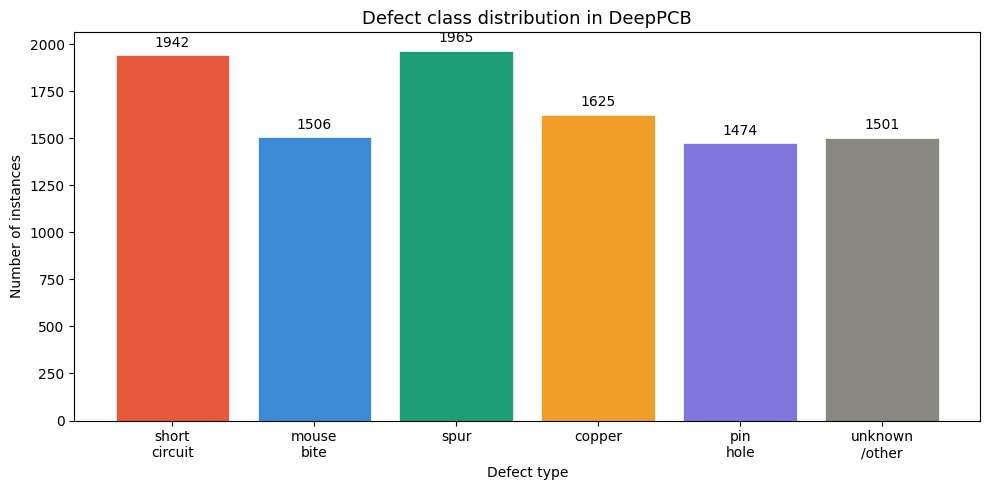

In [ ]:
classes = ['short\ncircuit', 'mouse\nbite', 'spur', 'copper', 'pin\nhole', 'unknown\n/other']
counts = [defect_counts[i] for i in [1, 2, 3, 4, 5, 6]]
colors = ['#E8593C', '#3B8BD4', '#1D9E75', '#EF9F27', '#7F77DD', '#888780']

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts, color=colors, edgecolor='white', linewidth=0.5)
plt.title('Defect class distribution in DeepPCB', fontsize=13)
plt.ylabel('Number of instances')
plt.xlabel('Defect type')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

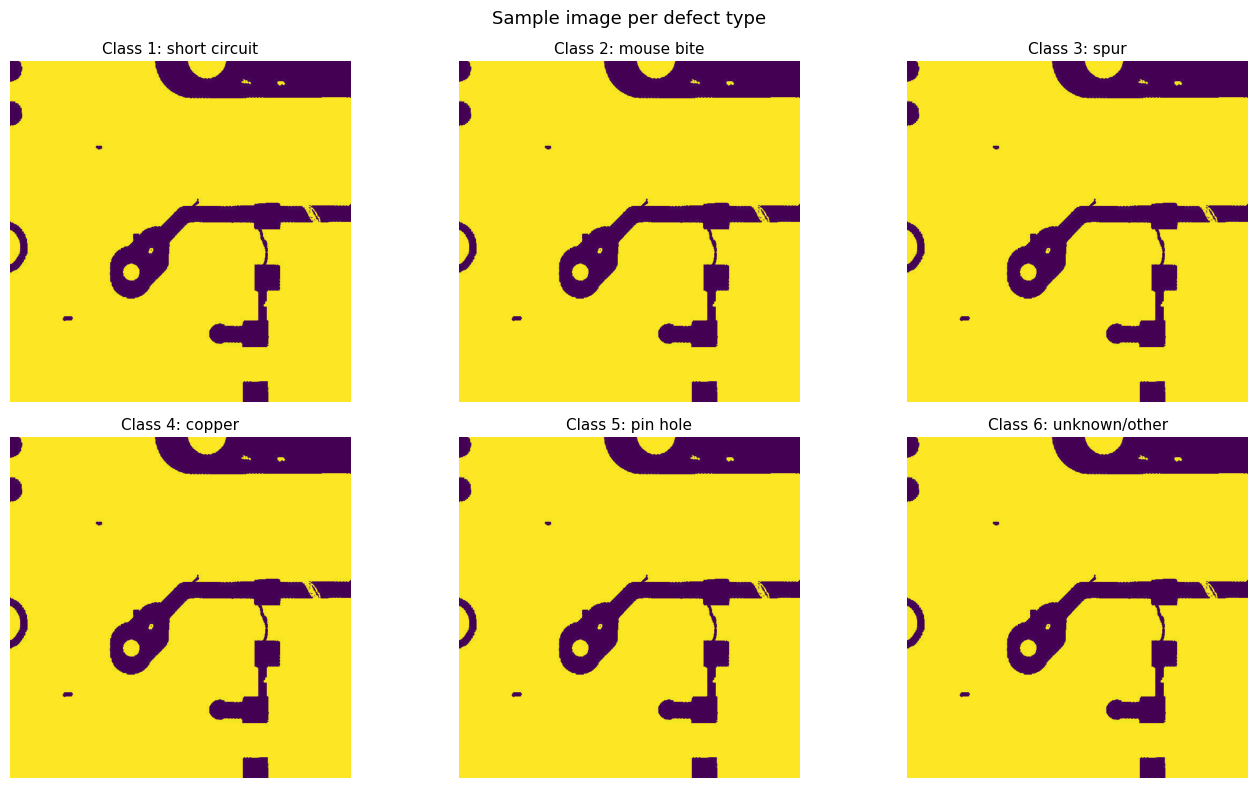

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

defect_names = {
    1: 'short circuit',
    2: 'mouse bite',
    3: 'spur',
    4: 'copper',
    5: 'pin hole',
    6: 'unknown/other'
}

found = {}

for group in board_folders:
    if len(found) == 6:
        break
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    not_folder = os.path.join(group_path, f'{board_id}_not')
    img_folder = os.path.join(group_path, board_id)

    if not os.path.exists(not_folder):
        continue

    for txt_file in os.listdir(not_folder):
        if not txt_file.endswith('.txt'):
            continue
        txt_path = os.path.join(not_folder, txt_file)
        with open(txt_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                cls = int(parts[4])
                if cls not in found and cls in defect_names:
                    img_name = txt_file.replace('.txt', '_test.jpg')
                    img_path = os.path.join(img_folder, img_name)
                    if os.path.exists(img_path):
                        found[cls] = img_path

for i, cls in enumerate(sorted(found.keys())):
    img = mpimg.imread(found[cls])
    axes[i].imshow(img)
    axes[i].set_title(f'Class {cls}: {defect_names[cls]}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample image per defect type', fontsize=13)
plt.tight_layout()
plt.show()

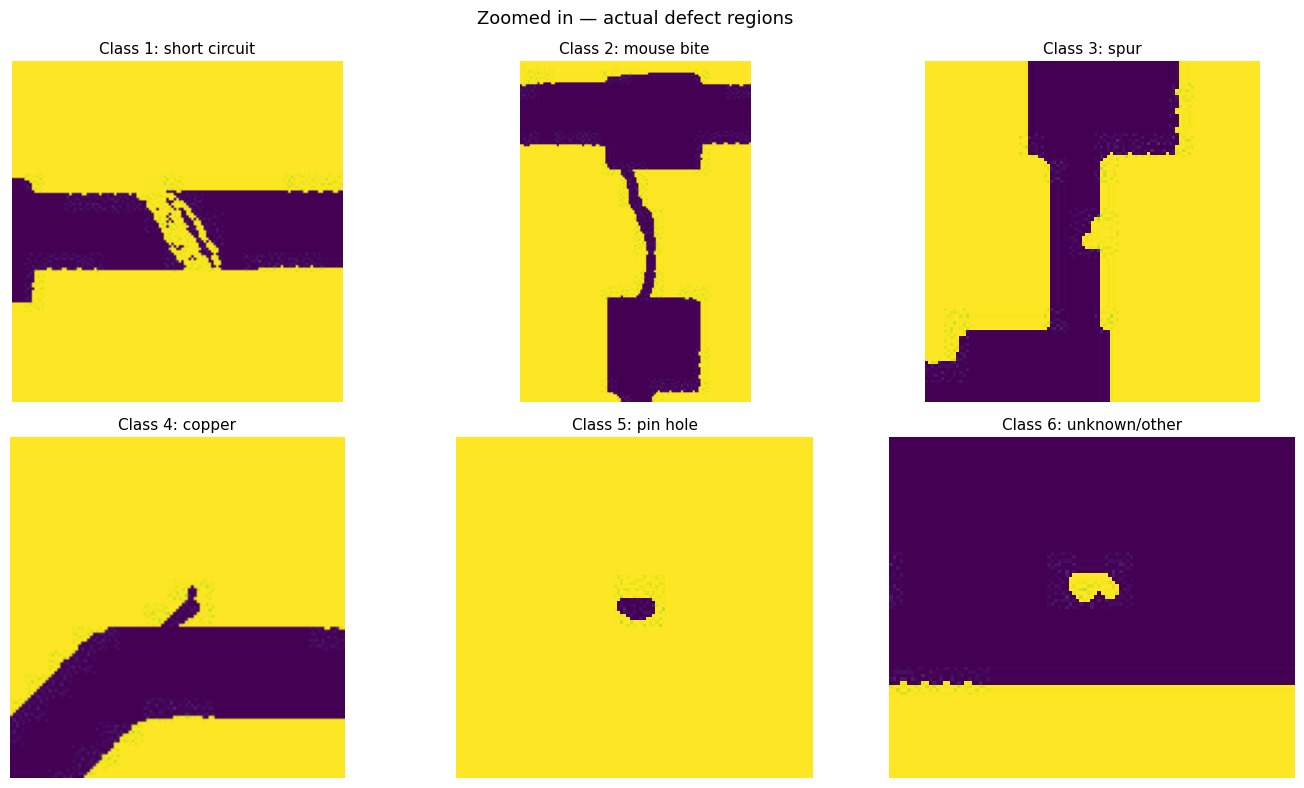

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

found_crops = {}

for group in board_folders:
    if len(found_crops) == 6:
        break
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    not_folder = os.path.join(group_path, f'{board_id}_not')
    img_folder = os.path.join(group_path, board_id)

    if not os.path.exists(not_folder):
        continue

    for txt_file in os.listdir(not_folder):
        if not txt_file.endswith('.txt'):
            continue
        txt_path = os.path.join(not_folder, txt_file)
        with open(txt_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                cls = int(parts[4])
                if cls not in found_crops and cls in defect_names:
                    img_name = txt_file.replace('.txt', '_test.jpg')
                    img_path = os.path.join(img_folder, img_name)
                    if os.path.exists(img_path):
                        x1, y1, x2, y2 = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                        # Add padding around defect
                        pad = 40
                        img = Image.open(img_path)
                        w, h = img.size
                        x1p = max(0, x1 - pad)
                        y1p = max(0, y1 - pad)
                        x2p = min(w, x2 + pad)
                        y2p = min(h, y2 + pad)
                        crop = img.crop((x1p, y1p, x2p, y2p))
                        found_crops[cls] = crop

for i, cls in enumerate(sorted(found_crops.keys())):
    axes[i].imshow(found_crops[cls])
    axes[i].set_title(f'Class {cls}: {defect_names[cls]}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Zoomed in — actual defect regions', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

records = []

for group in board_folders:
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    not_folder = os.path.join(group_path, f'{board_id}_not')
    img_folder = os.path.join(group_path, board_id)

    if not os.path.exists(not_folder):
        continue

    for txt_file in os.listdir(not_folder):
        if not txt_file.endswith('.txt'):
            continue

        txt_path = os.path.join(not_folder, txt_file)
        img_name = txt_file.replace('.txt', '_test.jpg')
        img_path = os.path.join(img_folder, img_name)

        if not os.path.exists(img_path):
            continue

        with open(txt_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                x1, y1, x2, y2, cls = (int(parts[0]), int(parts[1]),
                                        int(parts[2]), int(parts[3]), int(parts[4]))
                records.append({
                    'image_path': img_path,
                    'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                    'label': cls,
                    'group': group
                })

df = pd.DataFrame(records)
print(f"Total rows: {len(df)}")
print("\nLabel counts:")
print(df['label'].value_counts().sort_index())
print("\nFirst 5 rows:")
print(df.head())

Total rows: 1735

Label counts:
label
1    327
2    231
3    383
4    288
5    259
6    247
Name: count, dtype: int64

First 5 rows:
                                          image_path   x1   y1   x2   y2  \
0  /content/drive/MyDrive/pcb-defect-detection/da...  466  441  493  470   
1  /content/drive/MyDrive/pcb-defect-detection/da...  454  300  493  396   
2  /content/drive/MyDrive/pcb-defect-detection/da...  331  248  364  283   
3  /content/drive/MyDrive/pcb-defect-detection/da...  221  314  253  350   
4  /content/drive/MyDrive/pcb-defect-detection/da...  151  149  182  175   

   label       group  
0      3  group00041  
1      2  group00041  
2      4  group00041  
3      4  group00041  
4      5  group00041  


In [ ]:
print("Groups in board_folders:", board_folders)
print("\nGroups that appear in df:", sorted(df['group'].unique()))

Groups in board_folders: ['group00041', 'group12000', 'group12100']

Groups that appear in df: ['group00041', 'group12000']


In [ ]:
print("Folders in PCBData:")
for f in sorted(os.listdir(pcb_data_path)):
    print(f)

Folders in PCBData:
group00041
group12000
group12100


In [ ]:
import shutil

dataset_path = os.path.join(DATA_DIR, 'DeepPCB')
if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)
    print("Old incomplete folder removed.")

Old incomplete folder removed.


In [ ]:
pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))
print(f"Total groups: {len(board_folders)}")
print(board_folders)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/pcb-defect-detection/data/DeepPCB/PCBData'

In [ ]:
dataset_path = os.path.join(DATA_DIR, 'DeepPCB')
print("Does DeepPCB folder exist:", os.path.exists(dataset_path))
if os.path.exists(dataset_path):
    print("Contents:", os.listdir(dataset_path))

Does DeepPCB folder exist: False


In [ ]:
import os

dataset_path = os.path.join(DATA_DIR, 'DeepPCB')
print("Target path:", dataset_path)
print("Does DATA_DIR exist:", os.path.exists(DATA_DIR))

os.makedirs(dataset_path, exist_ok=True)
print("Created folder. Now exists:", os.path.exists(dataset_path))

!git clone https://github.com/tangsanli5201/DeepPCB.git {dataset_path}

print("\nAfter clone, contents of dataset_path:")
print(os.listdir(dataset_path) if os.path.exists(dataset_path) else "STILL DOESN'T EXIST")

Target path: /content/drive/MyDrive/pcb-defect-detection/data/DeepPCB
Does DATA_DIR exist: True
Created folder. Now exists: True
Cloning into '/content/drive/MyDrive/pcb-defect-detection/data/DeepPCB'...
remote: Enumerating objects: 4753, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4753 (delta 13), reused 12 (delta 12), pack-reused 4739 (from 1)
Receiving objects: 100% (4753/4753), 85.81 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (191/191), done.
Updating files: 100% (4548/4548), done.

After clone, contents of dataset_path:
['.git', '.gitignore', 'LICENSE', 'PCBData', 'README.md', 'evaluation', 'fig', 'tools']


In [ ]:
pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))
print(f"Total groups: {len(board_folders)}")
print(board_folders)

Total groups: 13
['group00041', 'group12000', 'group12100', 'group12300', 'group13000', 'group20085', 'group44000', 'group50600', 'group77000', 'group90100', 'group92000', 'test.txt', 'trainval.txt']


In [ ]:
pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted([f for f in os.listdir(pcb_data_path)
                        if os.path.isdir(os.path.join(pcb_data_path, f))])
print(f"Total groups: {len(board_folders)}")
print(board_folders)

Total groups: 11
['group00041', 'group12000', 'group12100', 'group12300', 'group13000', 'group20085', 'group44000', 'group50600', 'group77000', 'group90100', 'group92000']


In [ ]:
import pandas as pd

records = []

for group in board_folders:
    group_path = os.path.join(pcb_data_path, group)
    board_id = group.replace('group', '')
    not_folder = os.path.join(group_path, f'{board_id}_not')
    img_folder = os.path.join(group_path, board_id)

    if not os.path.exists(not_folder):
        continue

    for txt_file in os.listdir(not_folder):
        if not txt_file.endswith('.txt'):
            continue

        txt_path = os.path.join(not_folder, txt_file)
        img_name = txt_file.replace('.txt', '_test.jpg')
        img_path = os.path.join(img_folder, img_name)

        if not os.path.exists(img_path):
            continue

        with open(txt_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                x1, y1, x2, y2, cls = (int(parts[0]), int(parts[1]),
                                        int(parts[2]), int(parts[3]), int(parts[4]))
                records.append({
                    'image_path': img_path,
                    'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                    'label': cls,
                    'group': group
                })

df = pd.DataFrame(records)
print(f"Total rows: {len(df)}")
print("\nLabel counts:")
print(df['label'].value_counts().sort_index())

Total rows: 10013

Label counts:
label
1    1942
2    1506
3    1965
4    1625
5    1474
6    1501
Name: count, dtype: int64


In [ ]:
csv_path = os.path.join(DATA_DIR, 'defect_annotations.csv')
df.to_csv(csv_path, index=False)
print(f"Saved to {csv_path}")

Saved to /content/drive/MyDrive/pcb-defect-detection/data/defect_annotations.csv


In [ ]:
import os  #cell 12-crop every defect into its own saved image file
from PIL import Image

crops_dir = os.path.join(DATA_DIR, 'crops')
os.makedirs(crops_dir, exist_ok=True)

pad = 20  # pixels of context around each defect box
crop_records = []

for idx, row in df.iterrows():
    img_path = row['image_path']
    x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
    label = row['label']

    img = Image.open(img_path)
    w, h = img.size

    x1p = max(0, x1 - pad)
    y1p = max(0, y1 - pad)
    x2p = min(w, x2 + pad)
    y2p = min(h, y2 + pad)

    crop = img.crop((x1p, y1p, x2p, y2p))

    crop_filename = f"{idx:05d}_label{label}.jpg"
    crop_path = os.path.join(crops_dir, crop_filename)
    crop.save(crop_path)

    crop_records.append({'crop_path': crop_path, 'label': label})

    if idx % 1000 == 0:
        print(f"Processed {idx}/{len(df)}")

crops_df = pd.DataFrame(crop_records)
print(f"\nDone. Total crops saved: {len(crops_df)}")

crops_csv_path = os.path.join(DATA_DIR, 'crops_labels.csv')
crops_df.to_csv(crops_csv_path, index=False)
print(f"Saved crop index to {crops_csv_path}")
#

Processed 0/10013
Processed 1000/10013
Processed 2000/10013
Processed 3000/10013
Processed 4000/10013
Processed 5000/10013
Processed 6000/10013
Processed 7000/10013
Processed 8000/10013
Processed 9000/10013
Processed 10000/10013

Done. Total crops saved: 10013
Saved crop index to /content/drive/MyDrive/pcb-defect-detection/data/crops_labels.csv


In [ ]:
import torch #Cell 13 — the PyTorch Dataset class
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class PCBDefectDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['crop_path']).convert('RGB')
        label = int(row['label']) - 1  # shift labels 1-6 to 0-5 for PyTorch

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
IMG_SIZE = 224  # EfficientNet-B0's expected input size
#Cell 14 — transforms pipeline
# ImageNet normalization stats — required when using ImageNet-pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms ready.")

Transforms ready.


In [ ]:
from sklearn.model_selection import train_test_split  #Cell 15 — train/val split and DataLoaders
from torch.utils.data import DataLoader

train_df, val_df = train_test_split(
    crops_df,
    test_size=0.2,
    stratify=crops_df['label'],
    random_state=42
)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")

train_dataset = PCBDefectDataset(train_df, transform=train_transform)
val_dataset = PCBDefectDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train samples: 8010
Val samples: 2003

Train batches: 251
Val batches: 63


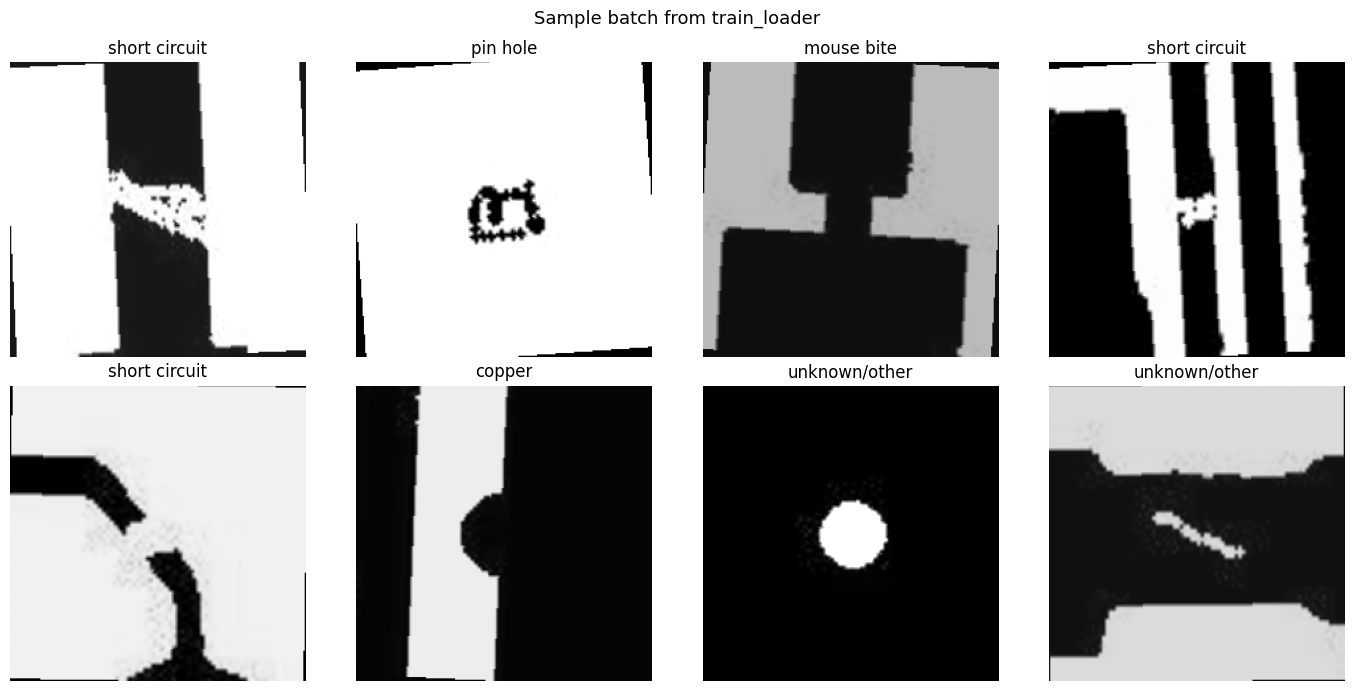

In [ ]:
import matplotlib.pyplot as plt
#Cell 16 — sanity check: plot a batch

images, labels = next(iter(train_loader))

defect_names = {0: 'short circuit', 1: 'mouse bite', 2: 'spur',
                 3: 'copper', 4: 'pin hole', 5: 'unknown/other'}

# Unnormalize for display
def unnormalize(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img * std + mean

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    img = unnormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(defect_names[labels[i].item()])
    axes[i].axis('off')

plt.suptitle('Sample batch from train_loader', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import os
print("DATA_DIR contents:")
print(os.listdir(DATA_DIR))